#  MuJoCo Bootcamp : 2D Biped

---- 

- conda env : [ai_robotics](../../../README.md#setup-a-conda-environment)

---


### Reference : 
- https://pab47.github.io/mujoco.html
- https://youtu.be/VnTkskLVfVA

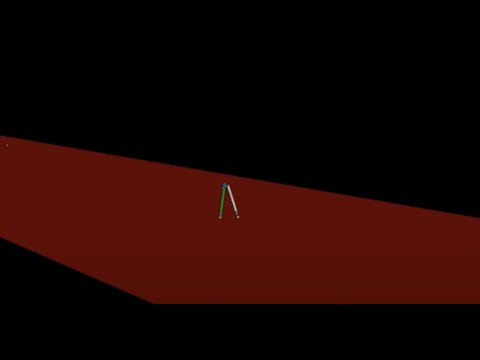

In [1]:
from IPython.display import YouTubeVideo

YouTubeVideo('VnTkskLVfVA')

## Run python code

In [ ]:
!python biped.py

## Jupyter code

### Load XML file and build model and data

In [1]:
import mujoco as mj
import numpy as np
import mediapy as media
from numpy.linalg import inv
from scipy.linalg import solve_continuous_are
import os
from scipy.spatial.transform import Rotation as R

# Create an XML file string for a simple ball on a plane
xml_path = "./biped.xml" 

# MuJoCo data structures
model = mj.MjModel.from_xml_path(xml_path)  # MuJoCo model
data = mj.MjData(model)                # MuJoCo data


### Setup the controller

In [2]:
simend = 30

step_no = 0

FSM_LEG1_SWING = 0
FSM_LEG2_SWING = 1

FSM_KNEE1_STANCE = 0
FSM_KNEE1_RETRACT = 1

FSM_KNEE2_STANCE = 0
FSM_KNEE2_RETRACT = 1

fsm_hip = FSM_LEG2_SWING
fsm_knee1 = FSM_KNEE1_STANCE
fsm_knee2 = FSM_KNEE2_STANCE


def controller(model, data):
    """
    This function implements a controller that
    mimics the forces of a fixed joint before release
    """
    global fsm_hip
    global fsm_knee1
    global fsm_knee2
    global step_no

    # State Estimation
    quat_leg1 = data.xquat[1, :]
    euler_leg1 = quat2euler(quat_leg1)
    abs_leg1 = -euler_leg1[1]
    pos_foot1 = data.xpos[2, :]

    quat_leg2 = data.xquat[3, :]
    euler_leg2 = quat2euler(quat_leg2)
    abs_leg2 = -euler_leg2[1]
    pos_foot2 = data.xpos[4, :]

    # Transition check
    if fsm_hip == FSM_LEG2_SWING and pos_foot2[2] < 0.05 and abs_leg1 < 0.0:
        fsm_hip = FSM_LEG1_SWING
    if fsm_hip == FSM_LEG1_SWING and pos_foot1[2] < 0.05 and abs_leg2 < 0.0:
        fsm_hip = FSM_LEG2_SWING

    if fsm_knee1 == FSM_KNEE1_STANCE and pos_foot2[2] < 0.05 and abs_leg1 < 0.0:
        fsm_knee1 = FSM_KNEE1_RETRACT
    if fsm_knee1 == FSM_KNEE1_RETRACT and abs_leg1 > 0.1:
        fsm_knee1 = FSM_KNEE1_STANCE

    if fsm_knee2 == FSM_KNEE2_STANCE and pos_foot1[2] < 0.05 and abs_leg2 < 0.0:
        fsm_knee2 = FSM_KNEE2_RETRACT
    if fsm_knee2 == FSM_KNEE2_RETRACT and abs_leg2 > 0.1:
        fsm_knee2 = FSM_KNEE2_STANCE

    # Control
    if fsm_hip == FSM_LEG1_SWING:
        data.ctrl[0] = -0.5
    if fsm_hip == FSM_LEG2_SWING:
        data.ctrl[0] = 0.5

    if fsm_knee1 == FSM_KNEE1_STANCE:
        data.ctrl[2] = 0.0
    if fsm_knee1 == FSM_KNEE1_RETRACT:
        data.ctrl[2] = -0.25

    if fsm_knee2 == FSM_KNEE2_STANCE:
        data.ctrl[4] = 0.0
    if fsm_knee2 == FSM_KNEE2_RETRACT:
        data.ctrl[4] = -0.25

def init_controller(model,data):
    data.qpos[4] = 0.5
    data.ctrl[0] = data.qpos[4]

def quat2euler(quat):
    # SciPy defines quaternion as [x, y, z, w]
    # MuJoCo defines quaternion as [w, x, y, z]
    _quat = np.concatenate([quat[1:], quat[:1]])
    r = R.from_quat(_quat)

    # roll-pitch-yaw is the same as rotating w.r.t
    # the x, y, z axis in the world frame
    euler = r.as_euler('xyz', degrees=False)

    return euler

### Setup the configuration of render

In [3]:
# Offscreen rendering setup
width, height = 300, 400
renderer = mj.Renderer(model, width, height)

# Set camera configuration
cam = mj.MjvCamera()                        # Abstract camera
opt = mj.MjvOption()                        # visualization options
mj.mjv_defaultCamera(cam)
mj.mjv_defaultOption(opt)
# Set camera configuration
cam.azimuth = 120.89  # 89.608063
cam.elevation = -15.81  # -11.588379
cam.distance = 8.0  # 5.0
cam.lookat = np.array([0.0, 0.0, 2.0])

### Initialization 

In [4]:
#turn the direction of gravity to simulate a ramp
model.opt.gravity[0] = 9.81 * np.sin(0.1)
model.opt.gravity[2] = -9.81 * np.cos(0.1)

init_controller(model,data)

#set the controller
#mj.set_mjcb_control(controller)

### Simulation

In [5]:
# Store frames for visualization
frames = []
framerate = 60
# simend = 5

# mj.mj_resetData(model, data)
# init_controller(model,data)

while data.time < simend:
    simstart = data.time
    while (data.time - simstart < 1.0/60.0):
        #simulation step
        mj.mj_step(model, data)
        # Apply control
        controller(model, data)
    
    # Show joint frames
    opt.flags[mj.mjtVisFlag.mjVIS_JOINT] = 1

    # Update scene and render
    cam.lookat[0] = data.qpos[0] #camera follows the robot
    # Render the scene from the specified camera
    renderer.update_scene(data, camera=cam, scene_option=opt)
    
    # Get the rendered RGB image and store it
    rgb_image = renderer.render()
    frames.append(rgb_image)

media.show_video(frames, fps=framerate)



This browser does not support the video tag.
